<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml08_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Logistic Regression**

(주의) **분류** 알고리즘

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  # 분류 모델
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

# Fish 데이터셋

물고기의 모든 특성(무게, 길이, 대각선, 키, 두께)을 사용한 물고기 종류(Bream vs Smelt) 이진 분류

In [2]:
file_path = 'https://bit.ly/fish_csv_data'

In [3]:
fish = pd.read_csv(file_path)

In [4]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [5]:
df = fish[fish.Species.isin(['Bream', 'Smelt'])]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   49 non-null     object 
 1   Weight    49 non-null     float64
 2   Length    49 non-null     float64
 3   Diagonal  49 non-null     float64
 4   Height    49 non-null     float64
 5   Width     49 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.7+ KB


In [7]:
df.Species.value_counts()

,count
Species,
Bream,35
Smelt,14


In [8]:
x = df[df.columns[1:]].values  # 특성(features)
y = df.Species.values  # 타겟(target)

In [9]:
x[:5]

array([[242.    ,  25.4   ,  30.    ,  11.52  ,   4.02  ],
       [290.    ,  26.3   ,  31.2   ,  12.48  ,   4.3056],
       [340.    ,  26.5   ,  31.1   ,  12.3778,   4.6961],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [430.    ,  29.    ,  34.    ,  12.444 ,   5.134 ]])

In [10]:
y[:5]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

# 훈련 셋 vs 테스트 셋 나누기

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.25,
                                                    random_state=42,
                                                    stratify=y)  # 층화 추출

In [12]:
x_train.shape

(36, 5)

In [14]:
x_test.shape

(13, 5)

In [18]:
x_train[:5]

array([[720.    ,  35.    ,  40.6   ,  16.3618,   6.09  ],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [  8.7   ,  11.3   ,  12.6   ,   1.9782,   1.2852],
       [500.    ,  30.7   ,  36.2   ,  14.2266,   4.9594],
       [  9.8   ,  11.2   ,  12.4   ,   2.0832,   1.2772]])

In [17]:
y_train[:5]

array(['Bream', 'Bream', 'Smelt', 'Bream', 'Smelt'], dtype=object)

# Logistic Regression

*   Pipeline 생성
    *   StandardScaler + LogisticRegression
*   모델 훈련
*   모델 평가
    *   훈련 셋 분류 리포트 출력
    *   훈련 셋 혼동 행렬 시각화
    *   테스트 셋 분류 리포트 출력
    *   테스트 셋 혼동 행렬 시각화

## 모델 훈련

In [19]:
# 표준화 스케일링 + Logistic Regression ==> Pipeline
pipe = Pipeline(steps=[('scaler', StandardScaler()),
                       ('clf', LogisticRegression(random_state=42))])

In [20]:
# ML 모델 훈련
pipe.fit(X=x_train, y=y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(random_state=42))])

In [21]:
pipe['scaler'].mean_  # 훈련 셋에서 물고기 5개 특성의 평균값들.

array([441.98333333,  26.93333333,  31.01944444,  11.50641389,
         4.26155   ])

In [22]:
pipe['scaler'].var_  # 훈련 셋에서 물고기 5개 특성의 분산들.

array([1.06023830e+05, 1.01836667e+02, 1.41404900e+02, 3.66338767e+01,
       3.76707020e+00])

In [23]:
pipe['clf'].coef_ #> 물고기 5개 특성 변수에 곱해주는 계수들

array([[-0.55506377, -0.7878406 , -0.82200554, -0.85621658, -0.80176239]])

In [24]:
pipe['clf'].intercept_  # 선형회귀식의 절편

array([-2.70008196])

LogisticRegression은 훈련 데이터를 학습해서 분류를 위한 선형 회귀식
$ y = w_0 + x_1 \cdot w_1 + x_2 \cdot w_2 + x_3 \cdot w_3 + x_4 \cdot w_4 $
을 찾음.

## 모델 평가

### 훈련 셋 평가

In [25]:
train_pred = pipe.predict(X=x_train)  # 훈련 셋 예측값(도미/빙어)
print(train_pred)

['Bream' 'Bream' 'Smelt' 'Bream' 'Smelt' 'Bream' 'Smelt' 'Bream' 'Smelt'
 'Bream' 'Bream' 'Bream' 'Bream' 'Smelt' 'Smelt' 'Bream' 'Bream' 'Bream'
 'Smelt' 'Bream' 'Smelt' 'Bream' 'Smelt' 'Bream' 'Bream' 'Bream' 'Bream'
 'Smelt' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream']


In [26]:
y_train  # 훈련 셋 실젯값

array(['Bream', 'Bream', 'Smelt', 'Bream', 'Smelt', 'Bream', 'Smelt',
       'Bream', 'Smelt', 'Bream', 'Bream', 'Bream', 'Bream', 'Smelt',
       'Smelt', 'Bream', 'Bream', 'Bream', 'Smelt', 'Bream', 'Smelt',
       'Bream', 'Smelt', 'Bream', 'Bream', 'Bream', 'Bream', 'Smelt',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream'], dtype=object)

In [27]:
pipe.score(X=x_train, y=y_train)  # 훈련 셋 정확도

1.0

In [28]:
train_report = classification_report(y_true=y_train, y_pred=train_pred)
print(train_report)

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00        26
       Smelt       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [29]:
train_cm = confusion_matrix(y_true=y_train, y_pred=train_pred)
print(train_cm)

[[26  0]
 [ 0 10]]


In [31]:
target_names = ['Bream', 'Smelt']

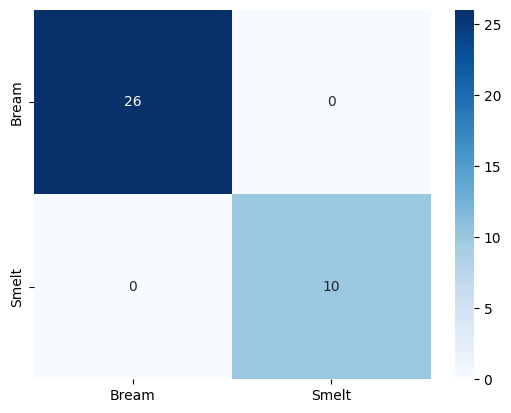

In [32]:
sns.heatmap(data=train_cm, cmap='Blues', annot=True,
            xticklabels=target_names, yticklabels=target_names)
plt.show()

### 테스트 셋 평가

In [34]:
test_pred = pipe.predict(X=x_test)  # 테스트 셋 (도미/빙어) 예측값

In [35]:
print(test_pred)

['Bream' 'Bream' 'Bream' 'Smelt' 'Smelt' 'Bream' 'Smelt' 'Bream' 'Smelt'
 'Bream' 'Bream' 'Bream' 'Bream']


In [36]:
print(y_test)

['Bream' 'Bream' 'Bream' 'Smelt' 'Smelt' 'Bream' 'Smelt' 'Bream' 'Smelt'
 'Bream' 'Bream' 'Bream' 'Bream']


In [37]:
test_report = classification_report(y_true=y_test, y_pred=test_pred)
print(test_report)

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         9
       Smelt       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



In [38]:
test_cm = confusion_matrix(y_true=y_test, y_pred=test_pred)
print(test_cm)

[[9 0]
 [0 4]]


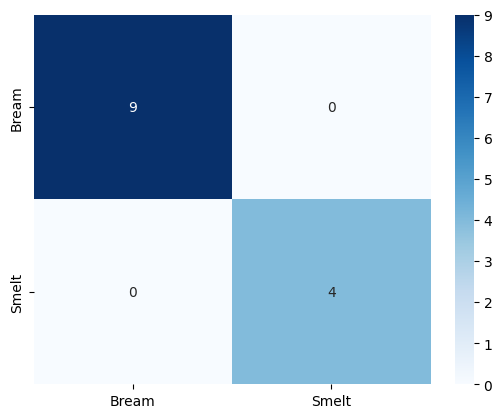

In [39]:
sns.heatmap(data=test_cm, cmap='Blues', annot=True,
            xticklabels=target_names, yticklabels=target_names)
plt.show()

# LogisticRegression의 분류 과정

In [42]:
train_pred_pr = pipe.predict_proba(X=x_train)  # 훈련 셋 예측(도미 vs 빙어) 확률
print(train_pred_pr[:5])

[[0.99729033 0.00270967]
 [0.95896655 0.04103345]
 [0.04270989 0.95729011]
 [0.98408167 0.01591833]
 [0.04237554 0.95762446]]


In [43]:
train_pred_pr.shape  #> (36, 2) = (n_samples, n_classes)

(36, 2)

Logistic Regression 이진 분류(binary-class classification) 원리

*   데이터를 학습하면서 선형 회귀식을 찾음.
    *   $ z_i
            = w_0 + x_{i1} \cdot w_1 + x_{i2} \cdot w_2 + \cdots
            = w_0 + \sum\limits_j x_{ij} \cdot w_j $
    
    *   분류 문제의 손실(비용) 함수를 최소로 하는 계수들과 절편을 찾음.   
*   회귀 방정식으로 계산된 결과를 **로지스틱 함수**(**시그모이드 함수**)의 아규먼트로 전달
    *   $ p_i = \phi(z_i)
              = \dfrac{1}{1 + e^{-z}}
              = \dfrac{1}{1 + exp(-(w_0 + \sum\limits_j x_{ij} \cdot w_j))} $
    
    *   로지스틱 함수의 리턴 값은 항상 0 ~ 1
    *   로지스틱 함수의 리턴 값을 양성이 될 확률(p)로 해석.
    *   음성이 될 확률은 1 - p.
*   이진 분류 문제의 손실 함수(**Logistic Loss, log loss**)
    *   $ Loss = -[y \log{p} + (1-y) \log{(1-p)}] $

    *   $ J(W) = - \dfrac{1}{N} \sum\limits_{i=1}^{N} [y^{(i)} \log({p}^{(i)}) + (1-y^{(i)}) \log(1 - {p}^{(i)})] $


## Sigmoid(Logistic) 함수

$
\phi(z) = \dfrac{e^z}{e^z + 1} = \dfrac{1}{1 + e^{-z}}
$

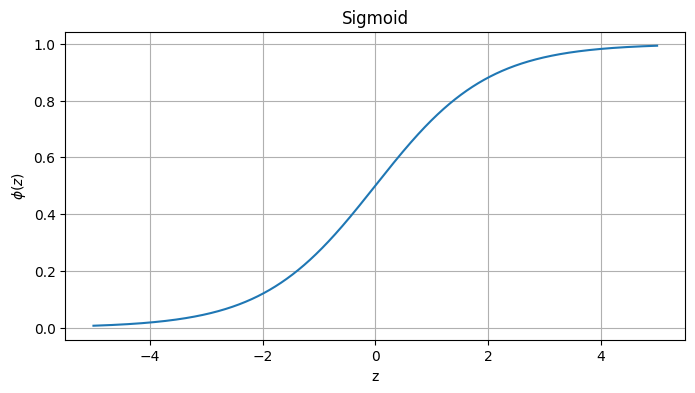

In [44]:
z = np.arange(-5, 5, 0.0001)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid)
plt.grid()
plt.title('Sigmoid')
plt.xlabel('z')
plt.ylabel(r'$\phi(z)$')
plt.show()

## 로그 함수

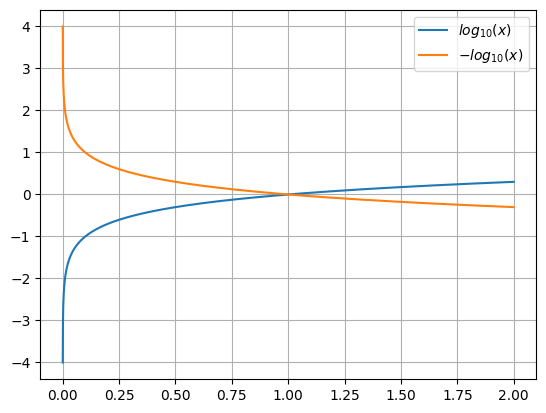

In [46]:
# 상용 로그(common log, 밑수가 10인 로그) 함수 시각화
x = np.arange(0.0001, 2.0, 0.0001)
y = np.log10(x)

plt.plot(x, y, label=r'$log_{10} (x)$')
plt.plot(x, -y, label=r'$-log_{10} (x)$')

plt.grid()
plt.legend()
plt.show()

# 다중 클래스 분류

다중 클래스 분류(multi-class classification)

*   **소프트맥스(Softmax) 함수**: 클래스 i가 될 확률

$$
\mathrm{softmax}{\mathbf(z)}_i = \dfrac{e^{z_i}}{\sum_{j=1}^{k} e^{z_j}}, \quad i = 1, \dots, k
$$

*   **크로스 엔트로피(corss entropy)**: 다중 클래스 분류의 손실 함수

$$
J(W) = - \dfrac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{m} y_{k}^{(i)} \log({p}_{k}^{(i)})
$$


*   fish 데이터 셋에서 Perch/Bream/Smelt 분류
*   특성 배열 x, 타겟 배열 y 생성
*   훈련 셋, 테스트 셋 분리
*   StandardScaler + LogisticRegression 훈련
    *   LogisticRegression 찾은 계수(coefficients)와 절편(intercepts) 출력.
*   예측, 평가
    *   훈련 셋
    *   테스트 셋

## 데이터 셋 준비

In [48]:
df = fish[fish.Species.isin(['Perch', 'Bream', 'Smelt'])]

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   105 non-null    object 
 1   Weight    105 non-null    float64
 2   Length    105 non-null    float64
 3   Diagonal  105 non-null    float64
 4   Height    105 non-null    float64
 5   Width     105 non-null    float64
dtypes: float64(5), object(1)
memory usage: 5.7+ KB


In [50]:
df.Species.value_counts()

,count
Species,
Perch,56
Bream,35
Smelt,14


In [51]:
df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [52]:
x = df[df.columns[1:]].values  # 특성 배열
y = df.Species.values  # 타겟 배열

In [53]:
x.shape

(105, 5)

In [54]:
y.shape

(105,)

## 훈련 셋 vs 테스트 셋 나누기

In [55]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.25,
                                                    random_state=42,
                                                    stratify=y)

In [56]:
pd.Series(y).value_counts(normalize=True)

,proportion
Perch,0.533333
Bream,0.333333
Smelt,0.133333


In [57]:
pd.Series(y_train).value_counts(normalize=True)

,proportion
Perch,0.538462
Bream,0.333333
Smelt,0.128205


In [58]:
pd.Series(y_test).value_counts(normalize=True)

,proportion
Perch,0.518519
Bream,0.333333
Smelt,0.148148


## Logistic Regression 훈련

In [59]:
pipe = Pipeline(steps=[('scaler', StandardScaler()),
                       ('clf', LogisticRegression(random_state=42))])

In [60]:
pipe.fit(X=x_train, y=y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(random_state=42))])

In [61]:
pipe['clf'].coef_
#> shape (3, 5) = (n_classes, n_features)
#> 3개의 확률을 계산하기 위한 계수들
#> 1개의 확률을 계산하기 위해 필요한 계수들의 개수는 특성들의 개수

array([[ 0.01184058, -0.10675492,  0.63328105,  2.44619756, -0.28427036],
       [ 0.26589069,  0.76751423, -0.09669006, -1.70526949,  1.45901222],
       [-0.27773127, -0.66075931, -0.53659099, -0.74092807, -1.17474186]])

In [62]:
pipe['clf'].intercept_
#> shape (3,) = (n_classes)
#> 3개의 확률을 계산하기 위해 필요한 절편들

array([ 1.10448426,  2.27582332, -3.38030758])

In [63]:
train_pred_pr = pipe.predict_proba(X=x_train)
#> train_pred_pr (확률) shape = (n_samples, n_classes)

In [64]:
train_pred_pr[:6]

array([[7.78665825e-01, 2.19970386e-01, 1.36378858e-03],
       [5.08581099e-03, 2.29357824e-01, 7.65556365e-01],
       [3.29513143e-02, 8.87008629e-01, 8.00400570e-02],
       [2.96349250e-03, 1.39726735e-01, 8.57309772e-01],
       [6.76821484e-02, 9.32298337e-01, 1.95147099e-05],
       [9.61234096e-01, 3.87566859e-02, 9.21784004e-06]])

## 훈련 셋 예측, 평가

In [65]:
train_pred = pipe.predict(X=x_train)

In [66]:
train_pred[:6]

array(['Bream', 'Smelt', 'Perch', 'Smelt', 'Perch', 'Bream'], dtype=object)

In [68]:
y_train[:6]

array(['Bream', 'Smelt', 'Perch', 'Smelt', 'Perch', 'Bream'], dtype=object)

In [69]:
target_names = ['Bream', 'Perch', 'Smelt']

In [70]:
train_report = classification_report(y_true=y_train, y_pred=train_pred)
print(train_report)

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00        26
       Perch       1.00      0.95      0.98        42
       Smelt       0.83      1.00      0.91        10

    accuracy                           0.97        78
   macro avg       0.94      0.98      0.96        78
weighted avg       0.98      0.97      0.98        78



In [71]:
train_cm = confusion_matrix(y_true=y_train, y_pred=train_pred)
print(train_cm)

[[26  0  0]
 [ 0 40  2]
 [ 0  0 10]]


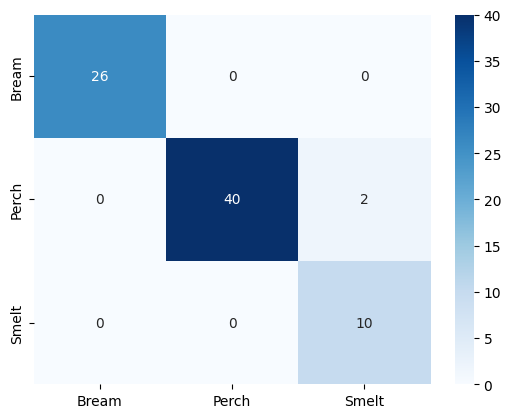

In [72]:
sns.heatmap(data=train_cm, cmap='Blues', annot=True,
            xticklabels=target_names, yticklabels=target_names)
plt.show()

## 테스트 셋 예측, 평가

In [73]:
test_pred = pipe.predict(X=x_test)

In [74]:
test_report = classification_report(y_true=y_test, y_pred=test_pred)
print(test_report)

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         9
       Perch       0.88      1.00      0.93        14
       Smelt       1.00      0.50      0.67         4

    accuracy                           0.93        27
   macro avg       0.96      0.83      0.87        27
weighted avg       0.94      0.93      0.92        27



In [75]:
test_cm = confusion_matrix(y_true=y_test, y_pred=test_pred)
print(test_cm)

[[ 9  0  0]
 [ 0 14  0]
 [ 0  2  2]]


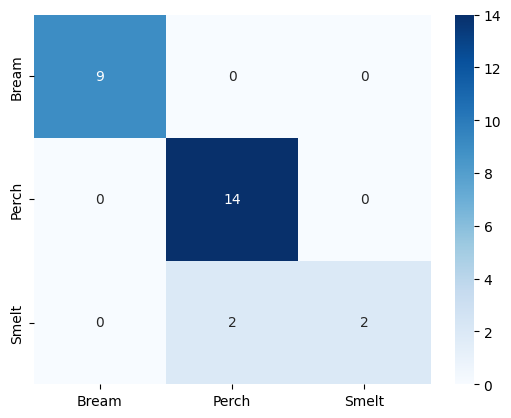

In [76]:
sns.heatmap(data=test_cm, cmap='Blues', annot=True,
            xticklabels=target_names, yticklabels=target_names)
plt.show()

# SGD Classification(분류)

*   확률적 경사 하강법 알고리즘(SGD)을 사용한 3개 클래스(Bream, Perch, Smelt) 분류 문제
*   StandardScaler + SGDClassifier ==> Pipeline
    *   SGDClassifier 생성자의 `loss` 파라미터는 'log_loss'로 설정.
    *   각 클래스가 될 확률을 계산할 수 있음.
*   훈련, 예측, 평가